# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Trend Based Strategy Using Camarilla Pivots

In the previous sections, you learnt to create strategies by making use of Woodie's pivots. But what if you wished to build a strategy that takes more frequent trades and captures directional price movements? 

For such a case, your best bet is to try out the Camarilla pivots. Camarilla pivots help us detect 6 unique levels of support and resistance each. And another interesting point to note here is that these levels tend to appear closer. And this makes it highly suitable for getting more frequent short term-trades.

Through this notebook, we will build a strategy that captures trend-based movements with the help of Camarilla pivots. This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Import the Data](#data)
3. [Resample the Data](#resample)
4. [Calculate the Camarilla Pivot Points](#pivots)
5. [Merge the Data](#merge)
6. [Generate the Trading Signals](#signals)
7. [Backtest the Strategy](#backtest)
8. [Trade Level Analytics](#trade-level-analytics)
9. [Strategy Performance](#performance)
10. [Summary and Next Steps](#summary)

<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# Ignore warnings
import warnings 
warnings.filterwarnings('ignore')

# For datetime manipulation
from datetime import timedelta

# Import utility functions 
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import intraday_backtester, trade_level_analytics, get_performance_metrics

<a id='data'></a>
## Import the Data

From the `data_modules` folder, let's import the minute-wise price data of the Apple stock which is stored in a CSV file named `apple_1_minute_2015_2021.csv`. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

We will use the `read_csv` method of `pandas` to import the data and then store it in a dataframe named `data`.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/apple_1_minute_2015_2021.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Print the first 5 rows of the data
data.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.800,27.810
2015-01-02 09:31:00+00:00,27.8100,27.8475,27.785,27.825
2015-01-02 09:32:00+00:00,27.8250,27.8475,27.815,27.825
2015-01-02 09:33:00+00:00,27.8225,27.8250,27.780,27.795
2015-01-02 09:34:00+00:00,27.7950,27.8100,27.760,27.760


<a id='resample'></a>
## Resample the Data

For the trend based trading strategy using Camarilla pivots, we would need the resampled data in the daily and 5-min frequencies. The daily resampled data will be used for calculating the Camarilla pivot levels. And on the other hand, the 5-min resampled data will be used to determine the entry and exit signals.

In [3]:
# Aggregate function
ohlcv_dict = {'Open': 'first',
              'High': 'max',
              'Low': 'min',
              'Close': 'last'
              }

# Resample to 5 minutes frequency
data_5m = data.resample('5min', label='right',
                        closed='right').agg(ohlcv_dict).dropna()
data_5m.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,27.8000,27.8100
2015-01-02 09:35:00+00:00,27.8100,27.8475,27.7600,27.8025
2015-01-02 09:40:00+00:00,27.8050,27.8350,27.6575,27.6775
2015-01-02 09:45:00+00:00,27.6750,27.8525,27.6375,27.6475
2015-01-02 09:50:00+00:00,27.6500,27.6625,27.3150,27.3500


In [4]:
# Resample to daily frequency
data_daily = data.resample(
    '1d', label='left', closed='right').agg(ohlcv_dict).dropna()
data_daily.index += timedelta(hours=9, minutes=30)
data_daily.head()

,Open,High,Low,Close
2015-01-02 09:30:00+00:00,27.8475,27.8600,26.8375,27.3250
2015-01-05 09:30:00+00:00,27.0725,27.1625,26.3525,26.5625
2015-01-06 09:30:00+00:00,26.6700,26.8575,26.1575,26.5575
2015-01-07 09:30:00+00:00,26.7950,27.0500,26.6750,26.9375
2015-01-08 09:30:00+00:00,27.3075,28.0375,27.1750,27.9675


<a id='pivots'></a>
## Calculate the Camarilla Pivot Points

The following code for computing Camarilla pivots is the same as was covered earlier in the notebook on Visualise Camarilla Pivots. Note that we will compute the Camarilla pivots based on the daily frequency.

In [5]:
# Initialise the previous high, low, close and range
prev_high = data_daily['High'].shift(1)
prev_low = data_daily['Low'].shift(1)
prev_close = data_daily['Close'].shift(1)
prev_range = (prev_high - prev_low)

# Calculate the Camarilla pivot level
data_daily['P'] = (prev_high + prev_low + prev_close)/3

# Calculate the Camarilla H/Resistance levels
data_daily['H1'] = prev_close + prev_range * 1.1/12
data_daily['H2'] = prev_close + prev_range * 1.1/6
data_daily['H3'] = prev_close + prev_range * 1.1/4
data_daily['H4'] = prev_close + prev_range * 1.1/2
data_daily['H5'] = prev_close * (prev_high / prev_low)
data_daily['H6'] = data_daily['H5'] + 1.168 * \
    (data_daily['H5'] - data_daily['H4'])

# Calculate the Camarilla L/Support levels
data_daily['L1'] = prev_close - prev_range * 1.1/12
data_daily['L2'] = prev_close - prev_range * 1.1/6
data_daily['L3'] = prev_close - prev_range * 1.1/4
data_daily['L4'] = prev_close - prev_range * 1.1/2
data_daily['L5'] = prev_close - (data_daily['H5'] - prev_close)
data_daily['L6'] = prev_close - (data_daily['H6'] - prev_close)

# Drop all NaN values from the dataframe
data_daily.dropna(axis=0, how='any', inplace=True)
data_daily.head()

,Open,High,Low,Close,P,H1,H2,H3,H4,H5,H6,L1,L2,L3,L4,L5,L6
2015-01-05 09:30:00+00:00,27.0725,27.1625,26.3525,26.5625,27.340833,27.418729,27.512458,27.606188,27.887375,28.366074,28.925194,27.231271,27.137542,27.043812,26.762625,26.283926,25.724806
2015-01-06 09:30:00+00:00,26.6700,26.8575,26.1575,26.5575,26.692500,26.636750,26.711000,26.785250,27.008000,27.378955,27.812230,26.488250,26.414000,26.339750,26.117000,25.746045,25.312770
2015-01-07 09:30:00+00:00,26.7950,27.0500,26.6750,26.9375,26.524167,26.621667,26.685833,26.750000,26.942500,27.268204,27.648627,26.493333,26.429167,26.365000,26.172500,25.846796,25.466373
2015-01-08 09:30:00+00:00,27.3075,28.0375,27.1750,27.9675,26.887500,26.971875,27.006250,27.040625,27.143750,27.316190,27.517600,26.903125,26.868750,26.834375,26.731250,26.558810,26.357400
2015-01-09 09:30:00+00:00,28.1675,28.3125,27.5525,28.0000,27.726667,28.046563,28.125625,28.204688,28.441875,28.855153,29.337862,27.888438,27.809375,27.730313,27.493125,27.079847,26.597138


<a id='merge'></a>
## Merge the Data

In the following cells, you will merge and organise the daily and the 5-Minute frequency data for Apple into a single dataframe.

Since we are computing the Camarilla pivots on the daily frequency data, we will only require the data of the pivot levels from `data_daily`. These same pivot levels will then be referred to until the end of a trading day. That is, we will freeze the pivot levels obtained for the first 5-Minute Open until the last 5-Minute candle which would indicate the day's Close.

In [6]:
# Shortlist columns and prepare the data_daily for merging
data_daily = data_daily[['Open', 'P', 'H1', 'H2', 'H3',
                         'H4', 'H5', 'H6', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']]

# Rename Open to Open_daily
data_daily.columns = ['Open_daily', 'P', 'H1', 'H2', 'H3',
                      'H4', 'H5', 'H6', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']

Finally, we can carefully merge all of the above data with the 15-Minute dataframe and store all of it in a new dataframe `strategy_data`. The data corresponding to the 15-Minute timeframe will be used to generate your entry and exit signals.

In [7]:
# Merge the data of daily Camarilla levels with the 5min data
camarilla = pd.merge(data_5m, data_daily, left_index=True,
                     right_index=True, how='left')

# Forward fill the daily pivot levels to all 5min bars in a trading day
camarilla = camarilla.fillna(method='ffill')

# Drop the NaN values and display the data
camarilla = camarilla.dropna()
camarilla.head()

,Open,High,Low,Close,Open_daily,P,H1,H2,H3,H4,H5,H6,L1,L2,L3,L4,L5,L6
2015-01-05 09:30:00+00:00,27.0725,27.1150,26.9550,26.9925,27.0725,27.340833,27.418729,27.512458,27.606188,27.887375,28.366074,28.925194,27.231271,27.137542,27.043812,26.762625,26.283926,25.724806
2015-01-05 09:35:00+00:00,26.9975,27.1625,26.9725,27.1375,27.0725,27.340833,27.418729,27.512458,27.606188,27.887375,28.366074,28.925194,27.231271,27.137542,27.043812,26.762625,26.283926,25.724806
2015-01-05 09:40:00+00:00,27.1350,27.1425,26.9050,26.9875,27.0725,27.340833,27.418729,27.512458,27.606188,27.887375,28.366074,28.925194,27.231271,27.137542,27.043812,26.762625,26.283926,25.724806
2015-01-05 09:45:00+00:00,26.9850,27.1300,26.9625,27.1175,27.0725,27.340833,27.418729,27.512458,27.606188,27.887375,28.366074,28.925194,27.231271,27.137542,27.043812,26.762625,26.283926,25.724806
2015-01-05 09:50:00+00:00,27.1200,27.1250,26.9150,26.9250,27.0725,27.340833,27.418729,27.512458,27.606188,27.887375,28.366074,28.925194,27.231271,27.137542,27.043812,26.762625,26.283926,25.724806


<a id='signals'></a>
## Generate the Trading Signals

Further, if you recall from the video where we demonstrated the strategy logic, we checked for the likelihood of a trend-based movement. You can check for the following two conditions, to evaluate the same:

1. Day's Open < H3 Level
2. Day's Open > H4 Level

If both the above conditions are met, you can assign a value of `1` for the `trend_signal`.

In [8]:
# Specify the conditions for a trending scenario
cond_1 = camarilla['Open_daily'] > camarilla['H3']
cond_2 = camarilla['Open_daily'] < camarilla['H4']

# Generate signal values based on the above conditions
camarilla['trend_signal'] = np.where(cond_1 & cond_2, 1, 0)

Secondly, we will generate the `entry_signal`. Since H4 is selected to be our entry level, we will check for a 5-min close occurring above the H4 level.
* If a 5-min candle closes above H4, then the `entry_signal` = `1` 
* Otherwise, the `entry_signal` = `0`

In [9]:
# Check 5-min close above H4 level
camarilla['entry_signal'] = np.where(
    camarilla['Close'] >= camarilla['H4'], 1, 0)

### Final Trading Signal

We will only take trades if both the `trend_signal` as well as the `entry_signal` hold true (i.e. the value of both equals 1).

In [10]:
# Determine the value of the final trading signal
camarilla['signal'] = camarilla['trend_signal'] * camarilla['entry_signal']

### Risk Management

Since we are entering long positions only when prices close above R3, the exit levels can be placed in the following manner: 
* The `stoploss` can be placed at the H3 level. 
* And the `target` can be set at the H6 level.

In [11]:
# Determine the stop-loss level
camarilla['stoploss'] = camarilla['H3']

# Determine the take-profit level
camarilla['target'] = camarilla['H6']

<a id='backtest'></a>
## Backtest the Strategy

In the following cell, we will backtest the trend-based trading strategy by using the `intraday_backtester`. This function works in a similar manner as the `backtester` function that we have used earlier. However, the only difference here is that with the `intraday_backtester`, all open trades will be squared off 5 minutes before the closing time. That means, if our stop-loss or target levels are not hit by 15:50, we will exit the long position anyway at 15:55.

In [12]:
# Run the backtest using intraday_backtester
tradesheet = intraday_backtester(camarilla, intraday_exit=True)

Trade No: 1 | Entry Date: 2015-01-07 10:00:00+00:00 | Entry Price: 26.98 | Position: 1
Exit Type: Squareoff | Exit Date: 2015-01-07 15:55:00+00:00 | Exit Price: 26.94 | PnL: -0.04 | Cum PnL: -0.04
------------------------------
Trade No: 2 | Entry Date: 2015-01-22 11:05:00+00:00 | Entry Price: 27.77 | Position: 1
Exit Type: Squareoff | Exit Date: 2015-01-22 15:55:00+00:00 | Exit Price: 28.08 | PnL: 0.31 | Cum PnL: 0.27
------------------------------
Trade No: 3 | Entry Date: 2015-01-23 09:30:00+00:00 | Entry Price: 28.03 | Position: 1
Exit Type: SL | Exit Date: 2015-01-23 09:40:00+00:00 | Exit Price: 27.89 | PnL: -0.14 | Cum PnL: 0.13
------------------------------
Trade No: 4 | Entry Date: 2015-01-26 11:10:00+00:00 | Entry Price: 28.56 | Position: 1
Exit Type: SL | Exit Date: 2015-01-26 12:05:00+00:00 | Exit Price: 28.39 | PnL: -0.17 | Cum PnL: -0.04
------------------------------
Trade No: 5 | Entry Date: 2015-01-29 10:10:00+00:00 | Entry Price: 29.29 | Position: 1
Exit Type: Squareo

Trade No: 195 | Entry Date: 2018-01-02 09:50:00+00:00 | Entry Price: 42.71 | Position: 1
Exit Type: TP | Exit Date: 2018-01-02 13:45:00+00:00 | Exit Price: 42.92 | PnL: 0.21 | Cum PnL: 5.06
------------------------------
Trade No: 196 | Entry Date: 2018-01-02 13:55:00+00:00 | Entry Price: 42.9 | Position: 1
Exit Type: TP | Exit Date: 2018-01-02 14:05:00+00:00 | Exit Price: 42.98 | PnL: 0.08 | Cum PnL: 5.14
------------------------------
Trade No: 197 | Entry Date: 2018-01-02 14:15:00+00:00 | Entry Price: 43.01 | Position: 1
Exit Type: TP | Exit Date: 2018-01-02 14:25:00+00:00 | Exit Price: 43.01 | PnL: 0.0 | Cum PnL: 5.14
------------------------------
Trade No: 198 | Entry Date: 2018-01-02 14:35:00+00:00 | Entry Price: 43.0 | Position: 1
Exit Type: TP | Exit Date: 2018-01-02 14:45:00+00:00 | Exit Price: 43.0 | PnL: 0.0 | Cum PnL: 5.14
------------------------------
Trade No: 199 | Entry Date: 2018-01-02 14:55:00+00:00 | Entry Price: 43.0 | Position: 1
Exit Type: TP | Exit Date: 2018-0

Trade No: 231 | Entry Date: 2018-06-04 09:35:00+00:00 | Entry Price: 48.04 | Position: 1
Exit Type: Squareoff | Exit Date: 2018-06-04 15:55:00+00:00 | Exit Price: 47.97 | PnL: -0.07 | Cum PnL: 7.97
------------------------------
Trade No: 232 | Entry Date: 2018-06-05 09:30:00+00:00 | Entry Price: 48.33 | Position: 1
Exit Type: SL | Exit Date: 2018-06-05 09:50:00+00:00 | Exit Price: 48.18 | PnL: -0.15 | Cum PnL: 7.82
------------------------------
Trade No: 233 | Entry Date: 2018-06-21 09:35:00+00:00 | Entry Price: 46.8 | Position: 1
Exit Type: SL | Exit Date: 2018-06-21 10:45:00+00:00 | Exit Price: 46.64 | PnL: -0.16 | Cum PnL: 7.66
------------------------------
Trade No: 234 | Entry Date: 2018-06-29 09:35:00+00:00 | Entry Price: 46.71 | Position: 1
Exit Type: SL | Exit Date: 2018-06-29 10:20:00+00:00 | Exit Price: 46.56 | PnL: -0.15 | Cum PnL: 7.51
------------------------------
Trade No: 235 | Entry Date: 2018-07-24 09:40:00+00:00 | Entry Price: 48.37 | Position: 1
Exit Type: SL | E

Exit Type: SL | Exit Date: 2019-05-06 09:35:00+00:00 | Exit Price: 51.44 | PnL: -1.5 | Cum PnL: 6.9
------------------------------
Trade No: 271 | Entry Date: 2019-06-04 10:35:00+00:00 | Entry Price: 44.41 | Position: 1
Exit Type: Squareoff | Exit Date: 2019-06-04 15:55:00+00:00 | Exit Price: 44.89 | PnL: 0.48 | Cum PnL: 7.38
------------------------------
Trade No: 272 | Entry Date: 2019-06-05 09:30:00+00:00 | Entry Price: 46.2 | Position: 1
Exit Type: SL | Exit Date: 2019-06-05 10:55:00+00:00 | Exit Price: 45.38 | PnL: -0.82 | Cum PnL: 6.56
------------------------------
Trade No: 273 | Entry Date: 2019-06-07 09:45:00+00:00 | Entry Price: 46.88 | Position: 1
Exit Type: TP | Exit Date: 2019-06-07 10:40:00+00:00 | Exit Price: 47.62 | PnL: 0.74 | Cum PnL: 7.3
------------------------------
Trade No: 274 | Entry Date: 2019-06-07 10:50:00+00:00 | Entry Price: 47.67 | Position: 1
Exit Type: TP | Exit Date: 2019-06-07 11:00:00+00:00 | Exit Price: 47.86 | PnL: 0.19 | Cum PnL: 7.49
----------

Trade No: 310 | Entry Date: 2019-12-23 09:45:00+00:00 | Entry Price: 70.52 | Position: 1
Exit Type: Squareoff | Exit Date: 2019-12-23 15:55:00+00:00 | Exit Price: 71.0 | PnL: 0.48 | Cum PnL: 8.83
------------------------------
Trade No: 311 | Entry Date: 2019-12-24 09:30:00+00:00 | Entry Price: 71.12 | Position: 1
Exit Type: SL | Exit Date: 2019-12-24 09:40:00+00:00 | Exit Price: 70.98 | PnL: -0.14 | Cum PnL: 8.69
------------------------------
Trade No: 312 | Entry Date: 2020-01-16 09:45:00+00:00 | Entry Price: 78.71 | Position: 1
Exit Type: SL | Exit Date: 2020-01-16 11:05:00+00:00 | Exit Price: 78.37 | PnL: -0.34 | Cum PnL: 8.35
------------------------------
Trade No: 313 | Entry Date: 2020-01-16 15:55:00+00:00 | Entry Price: 78.74 | Position: 1
Exit Type: TP | Exit Date: 2020-01-24 09:40:00+00:00 | Exit Price: 80.34 | PnL: 1.6 | Cum PnL: 9.95
------------------------------
Trade No: 314 | Entry Date: 2020-02-04 11:30:00+00:00 | Entry Price: 79.49 | Position: 1
Exit Type: Squareoff

Trade No: 352 | Entry Date: 2020-11-27 09:40:00+00:00 | Entry Price: 116.98 | Position: 1
Exit Type: SL | Exit Date: 2020-11-27 12:25:00+00:00 | Exit Price: 116.43 | PnL: -0.55 | Cum PnL: 11.75
------------------------------
Trade No: 353 | Entry Date: 2020-11-30 09:35:00+00:00 | Entry Price: 117.99 | Position: 1
Exit Type: TP | Exit Date: 2020-11-30 09:45:00+00:00 | Exit Price: 119.06 | PnL: 1.07 | Cum PnL: 12.82
------------------------------
Trade No: 354 | Entry Date: 2020-11-30 09:55:00+00:00 | Entry Price: 119.1 | Position: 1
Exit Type: TP | Exit Date: 2020-11-30 10:05:00+00:00 | Exit Price: 119.2 | PnL: 0.1 | Cum PnL: 12.92
------------------------------
Trade No: 355 | Entry Date: 2020-11-30 10:15:00+00:00 | Entry Price: 118.93 | Position: 1
Exit Type: TP | Exit Date: 2020-11-30 10:25:00+00:00 | Exit Price: 118.8 | PnL: -0.13 | Cum PnL: 12.79
------------------------------
Trade No: 356 | Entry Date: 2020-11-30 10:35:00+00:00 | Entry Price: 118.33 | Position: 1
Exit Type: TP | 

Clearly, the camarilla pivots help in getting a higher number of trades. As you may have observed from the trade logs displayed above, the strategy has completed a total of 394 trades.

<a id='trade-level-analytics'></a>
## Trade Level Analytics
While calculating the PnL, we were only concerned with the entry and exit time. To calculate the equity curve, we will forward-fill the signal column with the position taken to get a clear idea of the strategy performance.

In [13]:
tradesheet.index = range(0, len(tradesheet))
camarilla.signal = 0

# Iterate over each row in the 'trades' DataFrame
for index, trade in tradesheet.iterrows():
    # Extract the entry date of the trade
    entry_time = tradesheet['entry_date'][index]
    
    # Extract the exit date of the trade
    exit_time = tradesheet['exit_date'][index]
    
    # Extract the position of the trade (e.g., -1 for short)
    position = tradesheet['position'][index]
    
    # Update the 'signal' column in the 'data' DataFrame for the date range
    # between the entry date and the exit date with the corresponding position
    camarilla.loc[entry_time:exit_time, 'signal'] = position

Using the `trade_level_analytics()` function,  calculate the trade level analytics.

In [14]:
# Trade level analytics
trade_level_analytics(tradesheet)

,Strategy
Total PnL,20.86
total_trades,394
Number of Winners,212
Number of Losers,182
Win (%),53.807107
Loss (%),46.192893
per_trade_PnL_winners,0.266274
per_trade_PnL_losers,0.195549
Average holding time,0 days 03:04:26.497461928
Profit Factor,1.58612


The Camarilla trend based strategy has generated 394 trades over the backtested period out of which 212 were profitable trades. The profit factor for this strategy is  1.58.

<a id='performance'></a>
## Strategy Performance
Analyse the strategy's performance by using the `get_performance_metrics()` function.

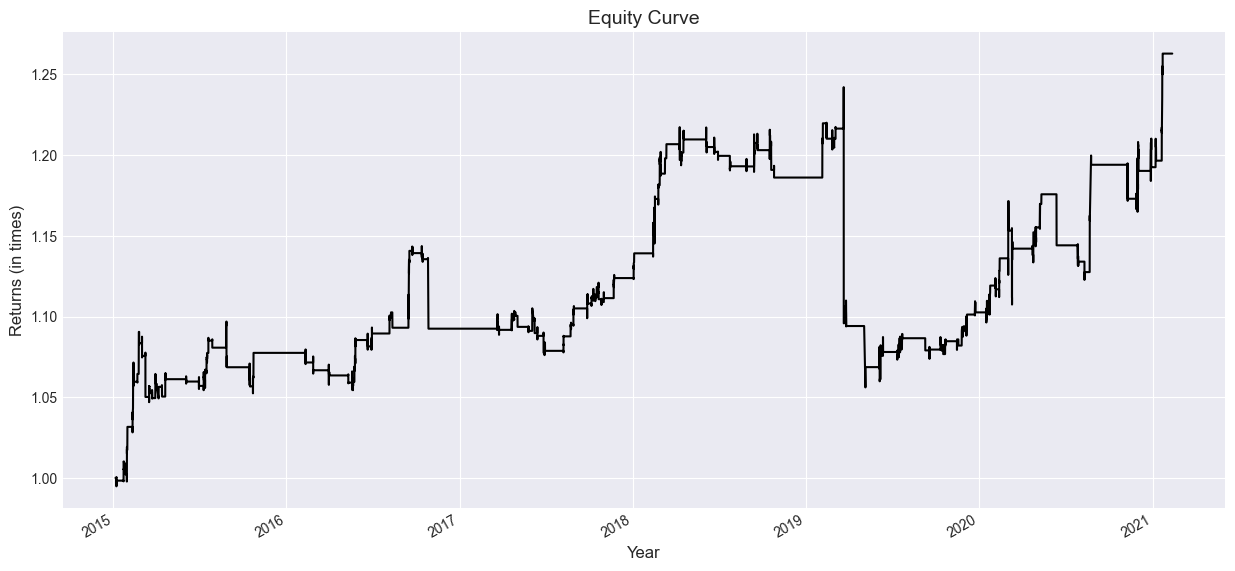

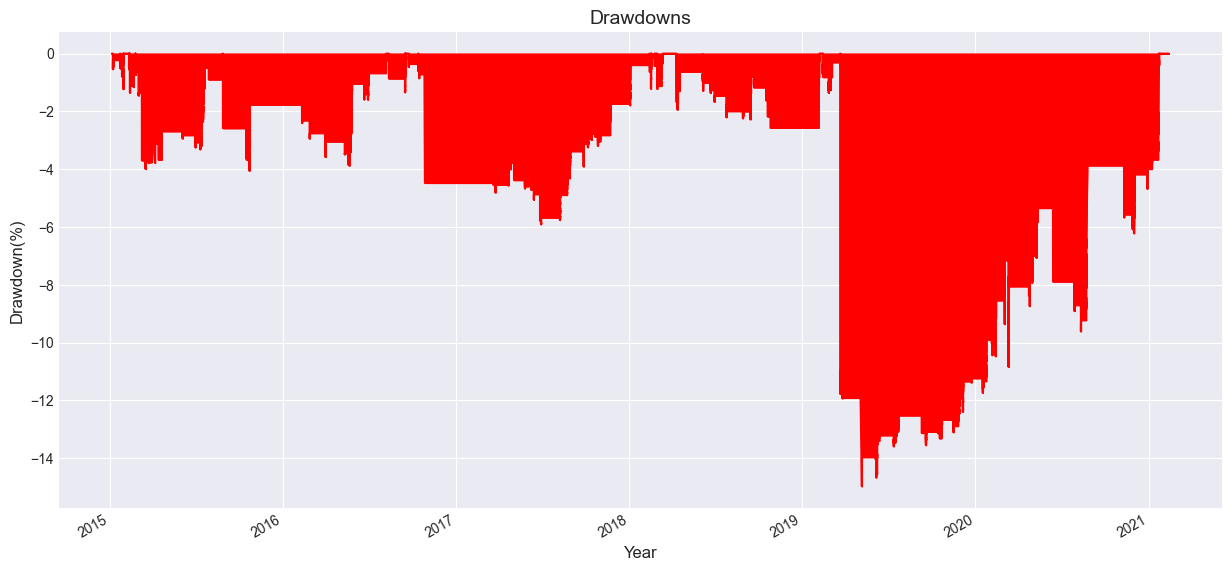

                 Strategy
CAGR                3.95%
Sharpe Ratio         0.31
Maximum Drawdown  -14.98%


In [15]:
# Strategy performance
get_performance_metrics(camarilla)

Over the backtested period, the strategy generated a CAGR of 3.95% with a Sharpe ratio of 0.31 and a maximum drawdown limited to -14.98%.

<a id='summary'></a>
## Summary and Next Steps

You have successfully built and backtested a trend-based trading strategy using the Camarilla pivots. Feel free to tweak all of the strategy parameters to customise the strategy as per your preference. 

In the upcoming section, you will be introduced to yet another interesting price action tool called the Fibonacci retracements. Stay tuned!  <br><br>